<a href="https://colab.research.google.com/github/VishalR787/Customer-churn-prediction-model/blob/main/Customer_churn_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Sample simulated customer churn data
data = {
    'Age': [25, 45, 39, 50, 30, 28, 55, 23, 40, 35],
    'MonthlyCharges': [50, 80, 70, 100, 60, 55, 90, 45, 75, 65],
    'Contract': ['Month-to-month', 'Two year', 'Month-to-month', 'One year', 'Two year',
                 'Month-to-month', 'One year', 'Month-to-month', 'Two year', 'One year'],
    'Tenure': [1, 24, 5, 18, 36, 3, 20, 2, 28, 12],
    'Churn': ['Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No']
}

df = pd.DataFrame(data)

In [3]:
# Encode categorical variables
le = LabelEncoder()
df['Contract'] = le.fit_transform(df['Contract'])  # Month-to-month: 0, One year: 1, Two year: 2
df['Churn'] = le.fit_transform(df['Churn'])        # Yes: 1, No: 0

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



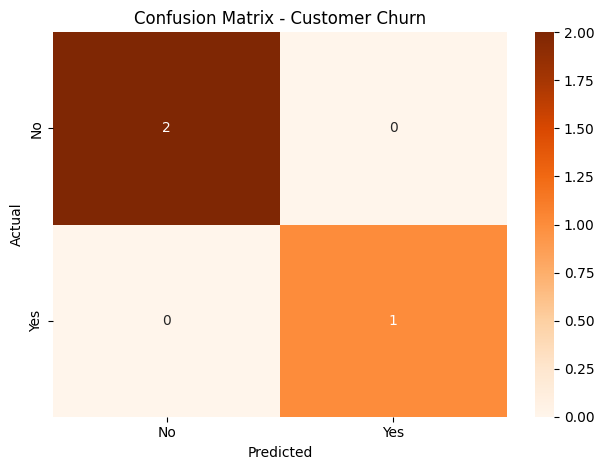

In [5]:
# Predict and evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix - Customer Churn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()